## Instalación requerida

In [ ]:
## Probado en tensorflow 2.13.1
!python -m pip install tensorflow==2.13.1 -q

In [2]:
## Recuerda cargar el archivo modificado de la librería keras_cv con capas separables
!python -m pip install keras_cv-0.9.0.1-py3-none-any.whl -qq

In [1]:
!python -m pip install pandas tqdm scikit-learn matplotlib opencv-python


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



  Using cached pandas-2.2.3-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached scikit_learn-1.6.1-cp312-cp312-win_amd64.whl.metadata (15 kB)
  Using cached matplotlib-3.10.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached opencv_python-4.11.0.86-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached pytz-2025.1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.1-py2.py3-none-any.whl.metadata (1.4 kB)
     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ------------ ------------------------- 20.5/60.8 kB 320.0 kB/s eta 0:00:01
     ------------------------- ------------ 41.0/60.8 kB 388.9 kB/s eta 0:00:01
     -------------------------------------- 60.8/60.8 kB 459.3 kB/s eta 0:00:00
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached threadpoolctl-3.5.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.1-cp312-cp312-win_amd64.whl.

## Library

In [1]:
import os
import json
import pandas as pd
import numpy as np
from tqdm import tqdm
import tensorflow as tf
print(tf.__version__)

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import average_precision_score

from keras_cv.models import YOLOV8Backbone, YOLOV8Detector
from keras_cv.layers import JitteredResize
from keras_cv.visualization import plot_bounding_box_gallery
from keras_cv import bounding_box
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

from tensorflow.keras.utils import plot_model
from tensorflow.ragged import constant

import matplotlib.pyplot as plt
import matplotlib.patches as patches

2.16.2


c:\Users\Usuario\OneDrive\Escritorio\Tesis DT\env_separable\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Funciones personalizadas

In [2]:
def visualize_dataset(inputs, value_range, rows, cols, bounding_box_format, class_mapping):
    inputs = next(iter(inputs.take(1)))
    images, bounding_boxes = inputs[0], inputs[1]

    plot_bounding_box_gallery(
        images,
        value_range=value_range,
        rows=rows,
        cols=cols,
        y_true=bounding_boxes,
        scale = 6,
        font_scale = 0.8,
        line_thickness=2,
        dpi = 100,
        bounding_box_format=bounding_box_format,
        class_mapping=class_mapping,
        true_color = (192, 57, 43))

In [3]:
def convert_box_values(row):
    
    inner_box = []
    ## Bbox coordinate transformation into xyxy format
    n_boxes = len(row['bbox'])
    for i in range(n_boxes):
        box = row['bbox'][i]
        x1 = float(box[0])
        y1 = float(box[1])
        w1 = float(box[2])
        h1 = float(box[3])

        xmin = int(x1)
        ymin = int(y1)
        xmax = int(x1 + w1)
        ymax = int(y1 + h1)

        inner_box.append([xmin ,ymin ,xmax ,ymax])
    
    return inner_box

In [4]:
# reading and resizing images
def img_preprocessing(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels = 3)
    img = tf.cast(img, tf.float32)

    return img

# loading dataset
def load_ds(img_paths, classes, bbox):
    img = img_preprocessing(img_paths)

    bounding_boxes = {
        "classes": tf.cast(classes, dtype=tf.float32),
        "boxes": bbox }

    return {"images": img, "bounding_boxes": bounding_boxes}

def dict_to_tuple(inputs):
    return inputs["images"], inputs["bounding_boxes"]

In [5]:
def visualize_predict_detections(model, dataset, bounding_box_format, class_mapping):
    images, y_true = next(iter(dataset.take(1)))

    y_pred = model.predict(images, verbose = 0)
    y_pred = bounding_box.to_ragged(y_pred)
    
    plot_bounding_box_gallery(
        images,
        value_range=(0, 255),
        bounding_box_format=bounding_box_format,
        y_true=y_true,
        y_pred=y_pred,
        true_color = (192, 57, 43),
        pred_color=(255, 235, 59),
        scale = 8,
        font_scale = 0.8,
        line_thickness=2,
        dpi = 100,
        rows=4,
        cols=3,
        show=True,
        class_mapping=class_mapping,
    )

In [6]:
## Funciones para el calculo de la métrica mAP

def iou(box1, box2):
    """Calcula la intersección sobre unión (IoU) entre dos cajas."""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    inter_area = max(0, x2 - x1) * max(0, y2 - y1)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    
    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area if union_area > 0 else 0

def compute_ap(true_boxes, pred_boxes, pred_confidences, iou_threshold=0.5):
    """Calcula el Average Precision (AP) para una clase."""
    
    if len(pred_boxes) == 0:
        return 0  # No predicciones
    
    sorted_indices = np.argsort(-np.array(pred_confidences))
    pred_boxes = [pred_boxes[i] for i in sorted_indices]
    pred_confidences = [pred_confidences[i] for i in sorted_indices]
    
    tp = np.zeros(len(pred_boxes))  # Verdaderos positivos
    fp = np.zeros(len(pred_boxes))  # Falsos positivos
    
    matched = set()
    for i, pbox in enumerate(pred_boxes):
        max_iou = 0
        matched_idx = -1
        for j, tbox in enumerate(true_boxes):
            iou_score = iou(pbox, tbox)
            if iou_score > max_iou:
                max_iou = iou_score
                matched_idx = j
        
        if max_iou >= iou_threshold and matched_idx not in matched:
            tp[i] = 1
            matched.add(matched_idx)
        else:
            fp[i] = 1
    
    fp_cumsum = np.cumsum(fp)
    tp_cumsum = np.cumsum(tp)
    precision = tp_cumsum / (tp_cumsum + fp_cumsum + 1e-10)
    recall = tp_cumsum / (len(true_boxes) + 1e-10)

    #print('precision: {} - recall: {}'.format(precision, recall))
    
    return np.trapz(precision, recall) if len(recall) > 0 else 0
    #return average_precision_score(recall, precision) if len(recall) > 1 else 0

def compute_map(y_true, y_pred, iou_threshold=0.5):
    """Calcula el Mean Average Precision (mAP)."""
    all_aps = []
    
    unique_classes = set(tf.concat([y_true['classes'].flat_values, y_pred['classes'].flat_values], axis=0).numpy())
    
    for class_id in unique_classes:
        true_boxes = [box.numpy() for i, box in enumerate(y_true['boxes']) if (y_true['classes'][i].numpy() == class_id).any()]
        pred_boxes = [box.numpy() for i, box in enumerate(y_pred['boxes']) if (y_true['classes'][i].numpy() == class_id).any()]
        pred_confidences = [conf.numpy() for i, conf in enumerate(y_pred['confidence']) if (y_true['classes'][i].numpy() == class_id).any()]
        
        if len(true_boxes) > 0 or len(pred_boxes) > 0:
            for tbox, pbox, pc in zip(true_boxes, pred_boxes, pred_confidences):
                ap = compute_ap(tbox, pbox, pc, iou_threshold)
                all_aps.append(ap)
        
    return np.mean(all_aps) if all_aps else 0

## Dataset

In [7]:
progress_bar = tqdm(total=5)

## Image and boxing paths
train_images_dir = 'coco2017/train2017'
val_images_dir = 'coco2017/val2017'

train_annotations_path = 'coco2017/annotations/instances_train2017.json'
val_annotations_path = 'coco2017/annotations/instances_val2017.json'

## Vinculado de las rutas con archivos
train_image_files = os.listdir(train_images_dir)
val_image_files = os.listdir(val_images_dir)

print(f'Total imágenes de entrenamiento: {len(train_image_files)}')
print(f'Total imágenes de validación: {len(val_image_files)}')

progress_bar.update(1)

with open(train_annotations_path, 'r') as f:
    train_annotations = json.load(f)
with open(val_annotations_path, 'r') as f:
    val_annotations = json.load(f)

train_df = pd.DataFrame(train_annotations['annotations'])
val_df = pd.DataFrame(val_annotations['annotations'])

train_df['image_file'] = train_df['image_id'].apply(lambda x: f"{x:012d}.jpg")
val_df['image_file'] = val_df['image_id'].apply(lambda x: f"{x:012d}.jpg")

train_df = train_df[train_df['image_file'].apply(lambda x: x in train_image_files)]
val_df = val_df[val_df['image_file'].apply(lambda x: x in val_image_files)]

train_df['image_path'] = train_df['image_file'].apply(lambda x: f'{train_images_dir}/{x}')
val_df['image_path'] = val_df['image_file'].apply(lambda x: f'{val_images_dir}/{x}')

print(f'Anotaciones de entrenamiento después de la verificación: {len(train_df)}')
print(f'Anotaciones de validación después de la verificación: {len(val_df)}')

progress_bar.update(1)

## ID's de las categorias
class_names = pd.DataFrame(train_annotations['categories'])
num_classes = len(class_names)
print(f'Número de clases: {num_classes}')

## Codificación de los IDs de las categorias.
label_encoder = LabelEncoder().fit(train_df['category_id'])
train_df['cat_label'] = label_encoder.transform(train_df['category_id'])
val_df['cat_label'] = label_encoder.transform(val_df['category_id'])

## Class mapping (key, class_name)
class_mapping = {}
for i, v in enumerate(class_names['name']):
    class_mapping[i] = v

## Preparación de información valido
train_info = train_df.groupby('image_path').apply(lambda x: x['bbox'].to_list()).reset_index()
train_info['cat_label'] = train_df.groupby('image_path').apply(lambda x: x['cat_label'].to_list()).to_list()
train_info.columns = ['image_path', 'bbox', 'cat_label']

val_info = val_df.groupby('image_path').apply(lambda x: x['bbox'].to_list()).reset_index()
val_info['cat_label'] = val_df.groupby('image_path').apply(lambda x: x['cat_label'].to_list()).to_list()
val_info.columns = ['image_path', 'bbox', 'cat_label']

print(f'Total imágenes de entrenamiento: {len(train_info)}')
print(f'Total imágenes de validación: {len(val_info)}')
progress_bar.update(1)

## Conversión de las coordenadas de los boxes de (x0, y0, w, h) a (x0, y0, x1, y1) 
## donde (x0, y0) es esquina inferior izq, (x1, y1) es esquina inferior derecho.
train_info['box_xyxy'] = train_info.apply(convert_box_values, axis=1)
val_info['box_xyxy'] = val_info.apply(convert_box_values, axis=1)
progress_bar.update(1)

train_img_paths = constant(train_info['image_path'].values) 
train_classes = constant(train_info['cat_label'].values)
train_bboxes = constant(train_info['box_xyxy'].values)

valid_img_paths = constant(val_info['image_path'].values) 
valid_classes = constant(val_info['cat_label'].values)
valid_bboxes = constant(val_info['box_xyxy'].values)
progress_bar.update(1)

 20%|██        | 1/5 [00:00<00:00,  6.32it/s]

Total imágenes de entrenamiento: 118287
Total imágenes de validación: 5000


 40%|████      | 2/5 [05:45<10:08, 202.96s/it]

Anotaciones de entrenamiento después de la verificación: 860001
Anotaciones de validación después de la verificación: 36781
Número de clases: 80


C:\Users\Usuario\AppData\Local\Temp\ipykernel_18880\1464121310.py:57: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_info = train_df.groupby('image_path').apply(lambda x: x['bbox'].to_list()).reset_index()
C:\Users\Usuario\AppData\Local\Temp\ipykernel_18880\1464121310.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_info['cat_label'] = train_df.groupby('image_path').apply(lambda x: x['cat_lab

Total imágenes de entrenamiento: 117266
Total imágenes de validación: 4952


100%|██████████| 5/5 [06:01<00:00, 46.89s/it] 

True

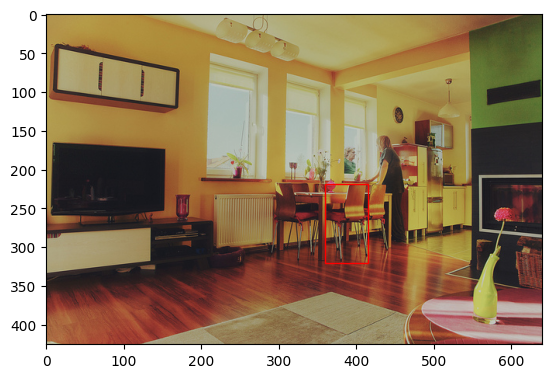

In [8]:
file = val_info['image_path'].iloc[0]
img = plt.imread(file)
box = val_info.iloc[0]['bbox'][3]

# Create figure and axes
fig, ax = plt.subplots()

# Display the image
ax.imshow(img)

# Create a Rectangle patch
rect = patches.Rectangle((box[0], box[1]), box[2], box[3], linewidth=1, edgecolor='r', facecolor='none')

# Add the patch to the Axes
ax.add_patch(rect)

plt.show()

## Generadores

In [9]:
BATCH_SIZE = 16
AUTO = tf.data.AUTOTUNE

resizing = JitteredResize(target_size=(640, 640),
                          scale_factor=(0.8, 1.25),
                          bounding_box_format="xyxy")

In [10]:
# Creating dataset loaders and tf.datasets
train_loader = tf.data.Dataset.from_tensor_slices((train_img_paths, train_classes, train_bboxes))
train_dataset = (train_loader
                 .map(load_ds, num_parallel_calls = AUTO)
                 .shuffle(BATCH_SIZE*10)
                 .ragged_batch(BATCH_SIZE, drop_remainder = True)
                 .map(resizing, num_parallel_calls = AUTO)
                 .map(dict_to_tuple, num_parallel_calls = AUTO)
                 .prefetch(AUTO))


valid_loader = tf.data.Dataset.from_tensor_slices((valid_img_paths, valid_classes, valid_bboxes))
valid_dataset = (valid_loader
                 .map(load_ds, num_parallel_calls = AUTO)
                 .ragged_batch(BATCH_SIZE, drop_remainder = True)
                 .map(resizing, num_parallel_calls = AUTO)
                 .map(dict_to_tuple, num_parallel_calls = AUTO)
                 .prefetch(AUTO))

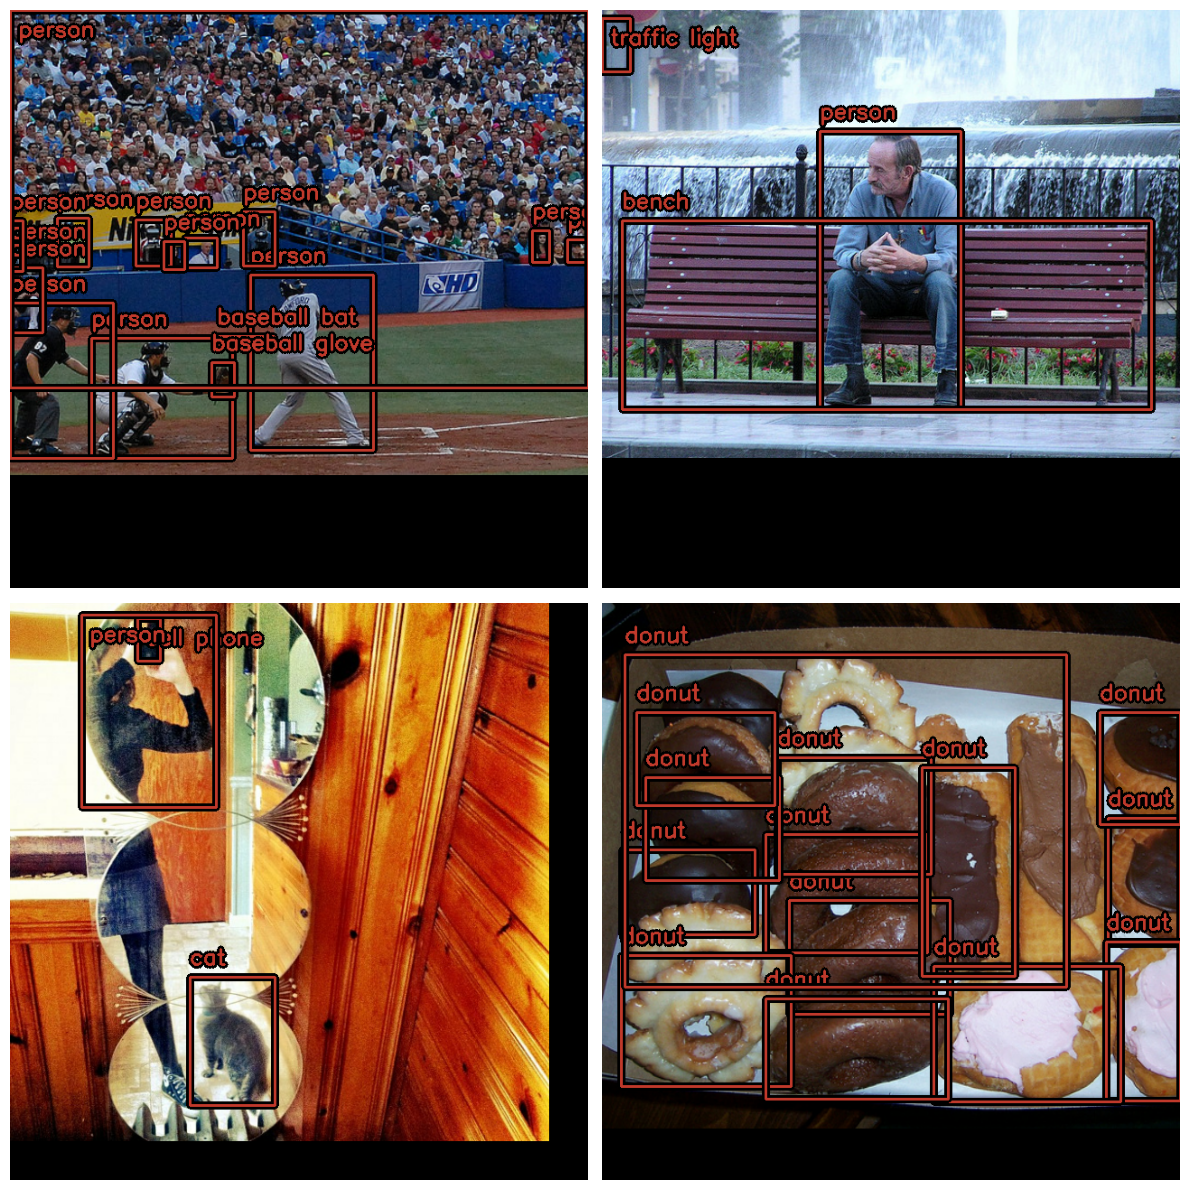

In [11]:
# examples images and annotations from training daatset
visualize_dataset(train_dataset, bounding_box_format="xyxy", 
                  value_range=(0, 255), rows=2, cols=2, class_mapping=class_mapping)

## Model

In [12]:
## Creating mirrored strategy
stg = tf.distribute.MirroredStrategy()

with stg.scope():

    ## Creating YOLOv8 model
    backbone = YOLOV8Backbone.from_preset("yolo_v8_xs_backbone", include_rescaling = True)
    YOLOV8_model = YOLOV8Detector(num_classes=num_classes,
                                  bounding_box_format = "xyxy", backbone = backbone, fpn_depth = 5)

    ## Optimizer selection
    optimizer = Adam(learning_rate=0.0007, weight_decay=0.0009, global_clipnorm = 10.0)

    ## Callbacks monitors
    my_callbacks = [ModelCheckpoint('YOLOv8_separable.weights.h5', monitor = 'val_loss', save_best_only = True, save_weights_only = True),
                    ReduceLROnPlateau(monitor='val_loss', factor=0.01, patience=8, verbose=0, min_delta=0.001),
                    EarlyStopping(monitor='val_loss', patience=20)]

    ## Compiler setting
    YOLOV8_model.compile(optimizer = optimizer, 
                         classification_loss = 'binary_crossentropy', 
                         box_loss = 'ciou')

## Model display
YOLOV8_model.summary()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)


Model: "yolov8_detector"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ [(None, None,     │    509,355 │ input_layer_1[0]… │
│ (Functional)        │ None, 64), (None, │            │                   │
│                     │ None, None, 128), │            │                   │
│                     │ (None, None,      │            │                   │
│                     │ None, 256)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat (Repeat)     │ (None, None,      │          0 │ functional[0][2]  │
│                     │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_1 (Repeat)   │ (None, None,      │          0 │ repeat[0][0]      │
│                     │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, None,      │          0 │ repeat_1[0][0],   │
│ (Concatenate)       │ None, 384)        │            │ functional[0][1]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_co… │ (None, None,      │     49,536 │ concatenate_5[0]… │
│ (SeparableConv2D)   │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_bn  │ (None, None,      │        512 │ pa_fpn_p4p5_pre_… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre     │ (None, None,      │          0 │ pa_fpn_p4p5_pre_… │
│ (Activation)        │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ split_4 (Split)     │ [(None, None,     │          0 │ pa_fpn_p4p5_pre[… │
│                     │ None, 64), (None, │            │                   │
│                     │ None, None, 64)]  │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │          0 │ split_4[0][1]     │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │      4,672 │ pa_fpn_p4p5_pre_… │
│ (SeparableConv2D)   │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │        256 │ pa_fpn_p4p5_pre_… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_1 │ (None, None,      │          0 │ pa_fpn_p4p5_pre_… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │          0 │ pa_fpn_p4p5_pre_… │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pa_fpn_p4p5_pre_0_… │ (None, None,      │      4,672 │ pa_fpn_p4p5_pre_… │
│ (SeparableConv2D)   │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,258,715 (4.80 MB)

 Trainable params: 1,245,819 (4.75 MB)

 Non-trainable params: 12,896 (50.38 KB)

In [13]:
history = YOLOV8_model.fit(train_dataset, validation_data = valid_dataset,  epochs = 10, callbacks = my_callbacks)

c:\Users\Usuario\OneDrive\Escritorio\Tesis DT\env_separable\Lib\site-packages\keras\src\models\functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(16, 640, 640, 3))
  warnings.warn(msg)


Epoch 1/10
7329/7329 ━━━━━━━━━━━━━━━━━━━━ 26274s 4s/step - box_loss: 2.6568 - class_loss: 18.9925 - loss: 21.6492 - val_box_loss: 2.0777 - val_class_loss: 0.0510 - val_loss: 2.1287 - learning_rate: 7.0000e-04
Epoch 2/10
7329/7329 ━━━━━━━━━━━━━━━━━━━━ 26054s 4s/step - box_loss: 2.0191 - class_loss: 0.0488 - loss: 2.0679 - val_box_loss: 1.9298 - val_class_loss: 0.0453 - val_loss: 1.9751 - learning_rate: 7.0000e-04
Epoch 3/10
7329/7329 ━━━━━━━━━━━━━━━━━━━━ 26200s 4s/step - box_loss: 1.8765 - class_loss: 0.0439 - loss: 1.9203 - val_box_loss: 1.8105 - val_class_loss: 0.0417 - val_loss: 1.8522 - learning_rate: 7.0000e-04
Epoch 4/10
7329/7329 ━━━━━━━━━━━━━━━━━━━━ 26225s 4s/step - box_loss: 1.7929 - class_loss: 0.0415 - loss: 1.8344 - val_box_loss: 1.7653 - val_class_loss: 0.0406 - val_loss: 1.8059 - learning_rate: 7.0000e-04
Epoch 5/10
7329/7329 ━━━━━━━━━━━━━━━━━━━━ 26486s 4s/step - box_loss: 1.7413 - class_loss: 0.0399 - loss: 1.7813 - val_box_loss: 1.7445 - val_class_loss: 0.0393 - val_loss

In [14]:
YOLOV8_model.save('Yolov8_separable.h5')

In [15]:
YOLOV8_model.load_weights('Yolov8_separable.h5')

In [ ]:
visualize_predict_detections(YOLOV8_model, dataset = valid_dataset, bounding_box_format="xyxy", class_mapping=class_mapping)

In [ ]:
##  Una manera de hacer la predicción 
images, y_true = next(iter(valid_dataset.take(1)))

## Lo que se requiere que la imagen es colocada en un tamaño de 640x640
y_pred = YOLOV8_model.predict(images, verbose = 0)

## Se decodifica los resultados. 
y_pred = bounding_box.to_ragged(y_pred)

## Calculo de mAP
map_score = compute_map(y_true, y_pred)
print(f"mAP: {map_score:.4f}")
